# Testing pybeepop

### Import required packages

In [1]:
from pybeepop import PyBeePop
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Create a PyBeePop object

By default, PyBeePop uses the Python engine (`engine='python'`) for maximum portability across platforms. If you want to use the original c++ binary engine, pass `engine='cpp'` explicitly.

In [3]:
beepop = PyBeePop(verbose=True)

### Choosing a Simulation Engine

**pybeepop+** supports two simulation engines:
- **Python engine**: Pure Python port and the default for maximum portability
- **C++ engine**: Original implementation, available when compiled binaries are present

Both engines produce virtually identical results (minor floating point calculation differences may exist). You can specify which engine to use with the `engine` parameter:

In [4]:
# Default behavior - use the Python engine
beepop_default = PyBeePop(verbose=True)

# Explicitly use C++ engine (requires compiled binaries)
# beepop_cpp = PyBeePop(engine='cpp', verbose=True)

# Explicitly use Python engine (maximum portability, no binary dependencies)
# beepop_python = PyBeePop(engine='python', verbose=True)

# Check which engine was loaded
print(f"Engine type: {beepop_default.engine_type}")

Engine type: python


### Set parameters, load example weather, parameter, and pesticide residue files

Example files are available on the project [GitHub page](https://github.com/USEPA/pybeepop/tree/main/example_data).

In [5]:
# Define inputs and file paths
START_DATE = '06/16/2014'
END_DATE = '10/10/2014'
run_parameters = {"ICWorkerAdults": 23000, "ICWorkerBrood": 8000, "SimStart": START_DATE, "SimEnd": END_DATE,
        'IPollenTrips': 8, 'INectarTrips': 17}
weather = os.path.abspath('example_data/cedar_grove_NC_weather.txt')
parameter_file = os.path.abspath('example_data/example_parameters.txt')
residue_file = os.path.abspath('example_data/example_residue_file.txt')

# Load inputs into BeePop+
beepop.load_weather(weather)
beepop.load_residue_file(residue_file)
beepop.load_parameter_file(parameter_file)
beepop.set_parameters(run_parameters)


### Run the model and print the results DataFrame

In [6]:
results = beepop.run_model()
print(results)

           Date  Colony Size  Adult Drones  Adult Workers  Foragers  \
0       Initial        23000             0          15561      7439   
1    06/16/2014        22874             0          15435      7439   
2    06/17/2014        22748             0          15309      7439   
3    06/18/2014        22622             0          15183      7439   
4    06/19/2014        22496             0          15057      7439   
..          ...          ...           ...            ...       ...   
113  10/06/2014        46611           558          25470     20583   
114  10/07/2014        46228           540          25232     20456   
115  10/08/2014        45797           522          24980     20295   
116  10/09/2014        43936           512          24672     18752   
117  10/10/2014        43445           500          24380     18565   

     Active Foragers  Capped Drone Brood  Capped Worker Brood  Drone Larvae  \
0               6900                   0                 8000       

### Saving model run results as a CSV file

In [5]:
results.to_csv("example_beepop_results.csv", index=False)

### Fetch a list of parameters that were set

In [6]:
beepop.get_parameters()

{'ICDroneAdults': '0',
 'icworkeradults': '8000',
 'ICDroneBrood': '0',
 'ICWorkerBrood': 8000,
 'ICDroneLarvae': '0',
 'ICWorkerLarvae': '2000',
 'ICDroneEggs': '0',
 'ICWorkerEggs': '0',
 'ICQueenStrength': '4.000000',
 'ICForagerLifespan': '10',
 'ICDroneAdultInfest': '0',
 'ICDroneBroodInfest': '0',
 'ICDroneMiteOffspring': '0',
 'ICDroneMiteSurvivorship': '0',
 'ICWorkerAdultInfest': '0',
 'ICWorkerBroodInfest': '0',
 'ICWorkerMiteOffspring': '0',
 'ICWorkerMiteSurvivorship': '0',
 'ImmEnabled': 'False',
 'RQEggLayDelay': '10',
 'RQEnableReQueen': 'False',
 'RQScheduled': 'False',
 'RQOnce': 'False',
 'VTEnable': 'False',
 'AIAdultSlope': '2.000000',
 'AIAdultLD50': '0.05',
 'AIAdultSlopeContact': '2.000000',
 'AIAdultLD50Contact': '999',
 'AILarvaSlope': '2.0000',
 'AILarvaLD50': '0.05',
 'AIKOW': '2.718282',
 'AIKOC': '1.000000',
 'AIHalfLife': '15.000000',
 'AIContactFactor': '0.330000',
 'CL4Pollen': '1.800000',
 'CL4Nectar': '60.0',
 'CL5Pollen': '3.600000',
 'CL5Nectar': '12

### Passing invalid parameters
If you pass a parameter that is not on the list of exposed parameters, an error message will be displayed.

In [7]:
new_parameters = {"InvalidParameter": 1234}
beepop.set_parameters(new_parameters)

BeepopParameterError: InvalidParameter is not a valid parameter.

### Plotting results

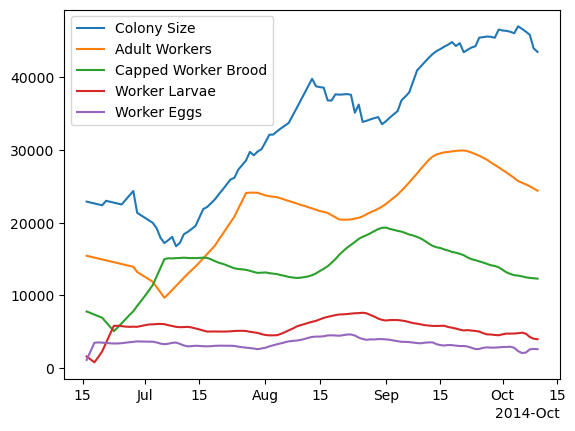

In [ ]:
ax = beepop.plot_output()

The matplotlib axes object created by plot_output() can be modified to create custom plots

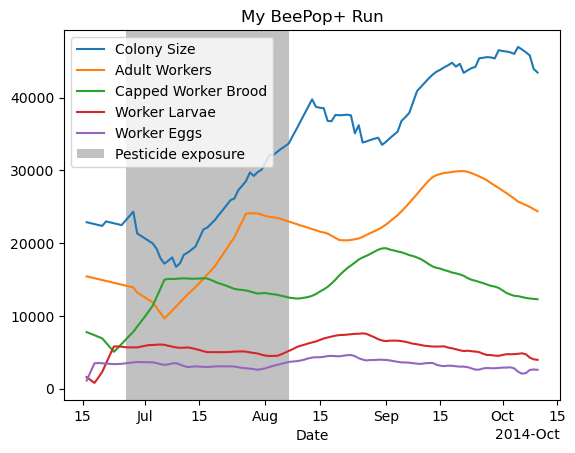

In [ ]:
ax.set_title("My BeePop+ Run")
ax.set_xlabel("Date")
ax.axvspan('2014-06-26', '2014-08-07',facecolor='0.2', alpha=0.3, label = "Pesticide exposure")
ax.legend()
ax.get_figure()

The user can also select which output columns they want to plot on the time series.

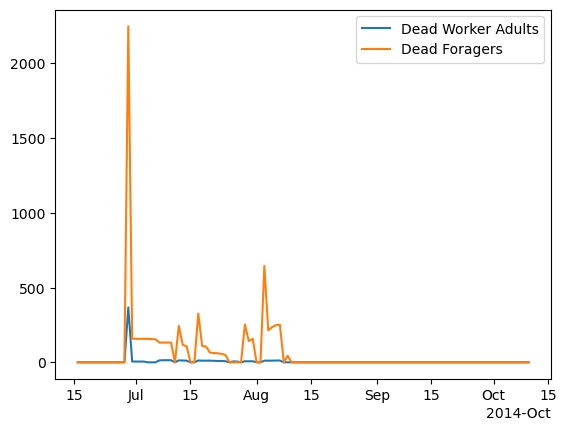

In [ ]:
cols_to_plot = ["Dead Worker Adults", "Dead Foragers"]
ax = beepop.plot_output(cols_to_plot)  # custom columns